<a href="https://colab.research.google.com/github/MiguelAngeloTr/Deep_Learning/blob/main/C2/Semana_8_CNNs_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Red Neuronal Convolucional**


---



Una red neuronal convolucional (CNN, por sus siglas en inglés) es un tipo de red neuronal artificial diseñada para procesar datos con una topología similar a la de una cuadrícula, como imágenes, que se pueden considerar como una cuadrícula de píxeles. Las CNNs son particularmente eficaces en tareas de visión por computadora, como el reconocimiento de imágenes y la clasificación, debido a su capacidad para capturar patrones espaciales y temporales en los datos.

Una CNN típica consta de varias capas que incluyen **capas convolucionales**, **capas de activación**, **capas de pooling (agrupación)** y, finalmente, **capas completamente conectadas**. La capa convolucional utiliza filtros o núcleos para realizar la convolución, extrayendo características de bajo nivel como bordes y gradualmente construyendo características de alto nivel a través de la red. La capa de activación, generalmente una función como ReLU, introduce no linealidades en el modelo, lo que permite aprender patrones más complejos. Las capas de pooling reducen la dimensionalidad de los datos, resumiendo las características en regiones más pequeñas para mejorar la eficiencia computacional y la robustez de la red.

Finalmente, después de varias capas convolucionales y de pooling, los datos se aplanan y se pasan a través de capas completamente conectadas, similares a las de una red neuronal tradicional, para realizar la clasificación o la regresión. Las CNNs aprenden a través del retropropagación y la optimización de un algoritmo, ajustando los pesos de los filtros para minimizar la función de pérdida, mejorando así la precisión de la predicción o clasificación del modelo.

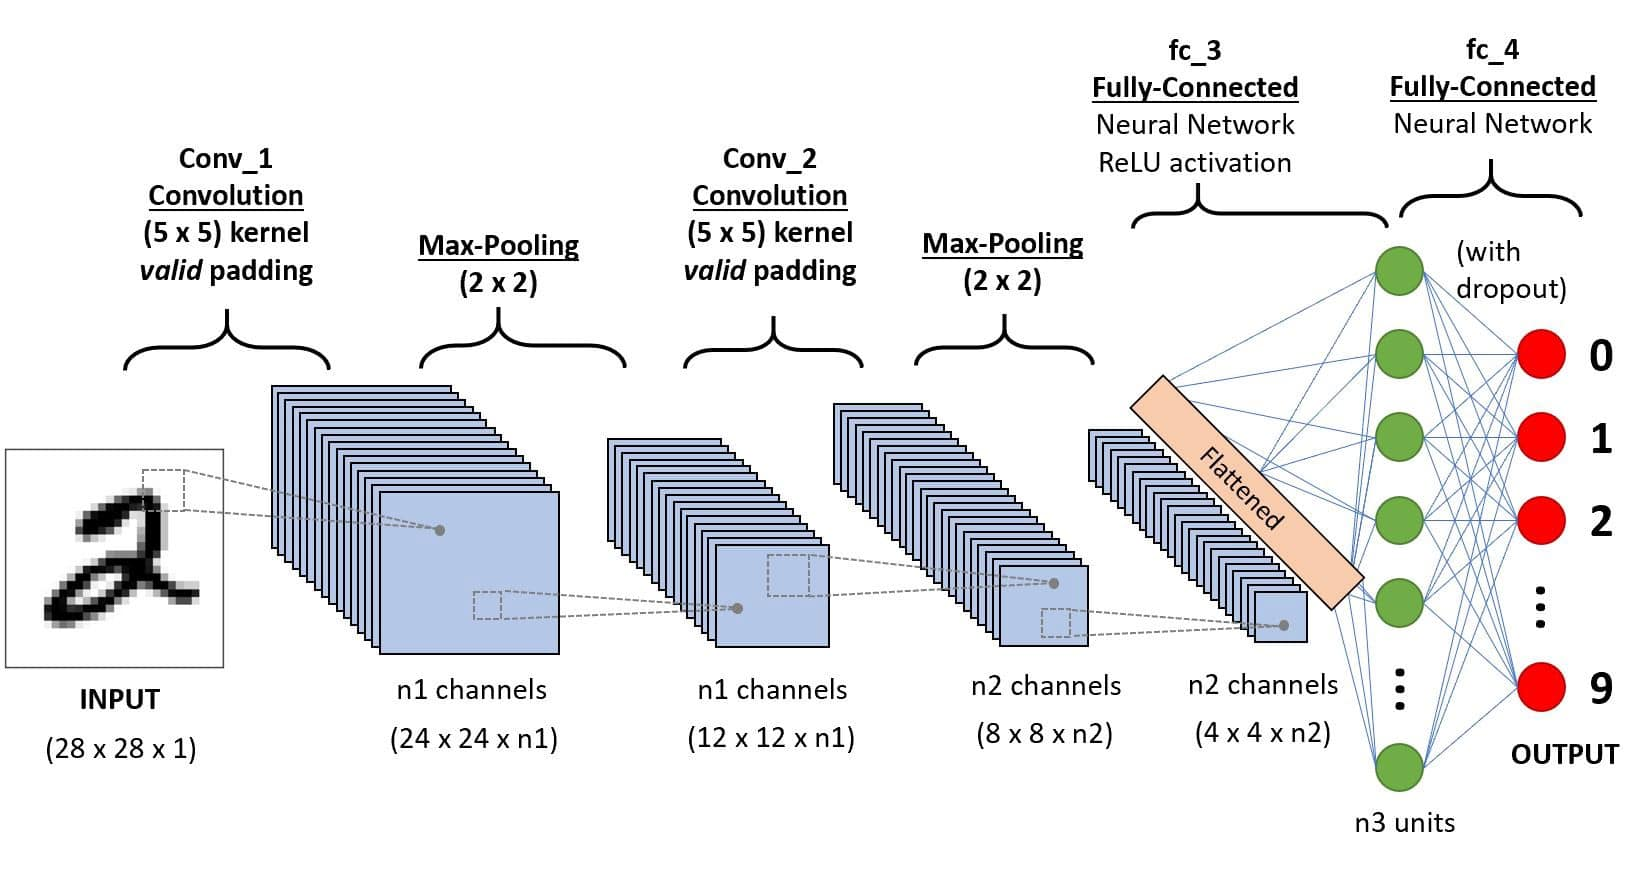

# **Flujo de Trabajo Basico**

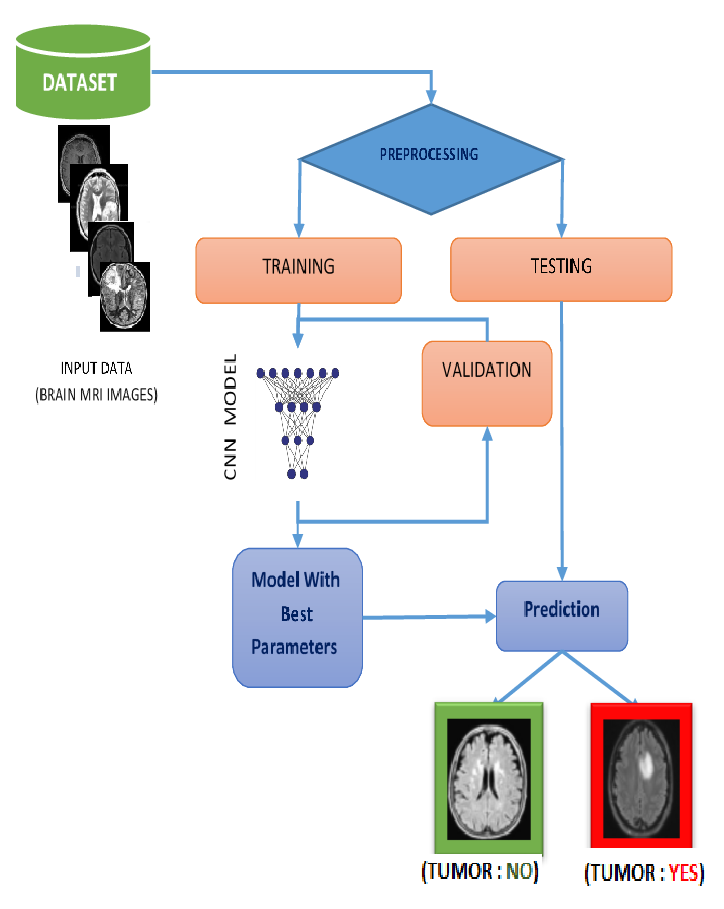

# **Preprocesamiento de imagenes**

Imagen Original:


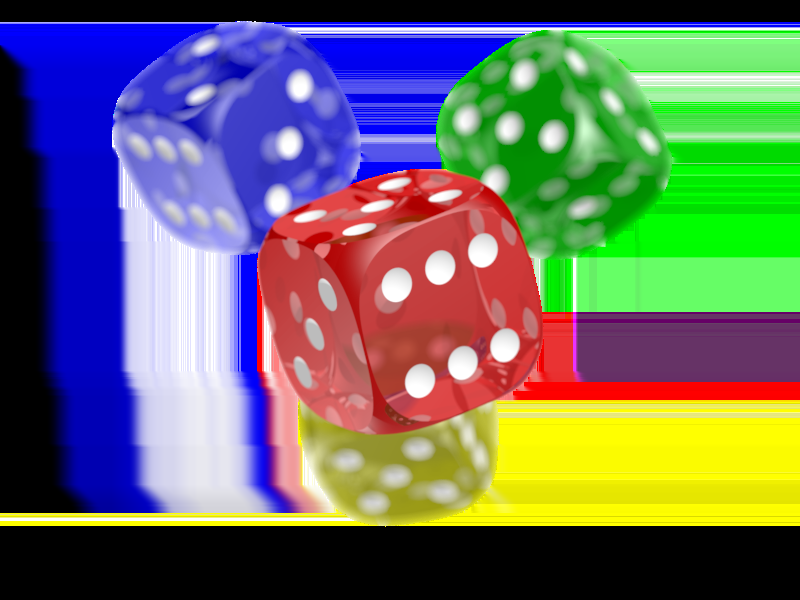

Imagen en Escala de Grises:


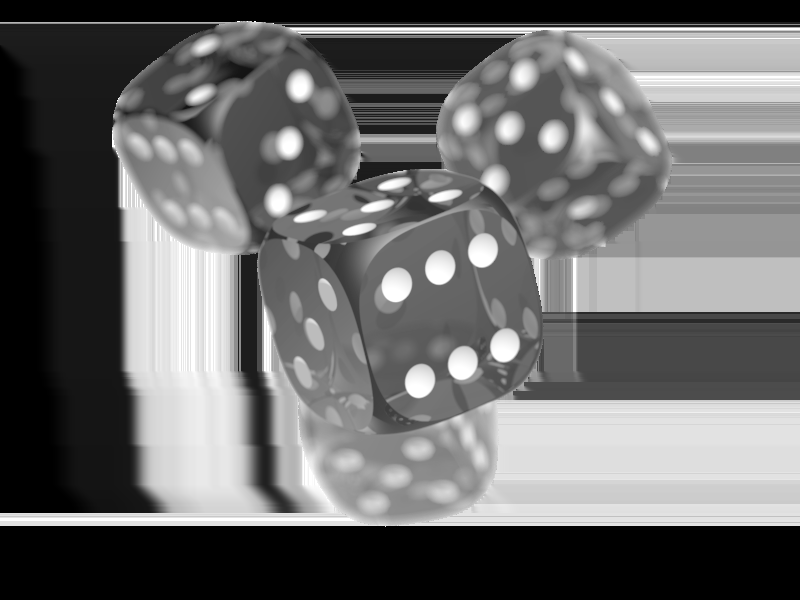

Imagen Desenfocada:


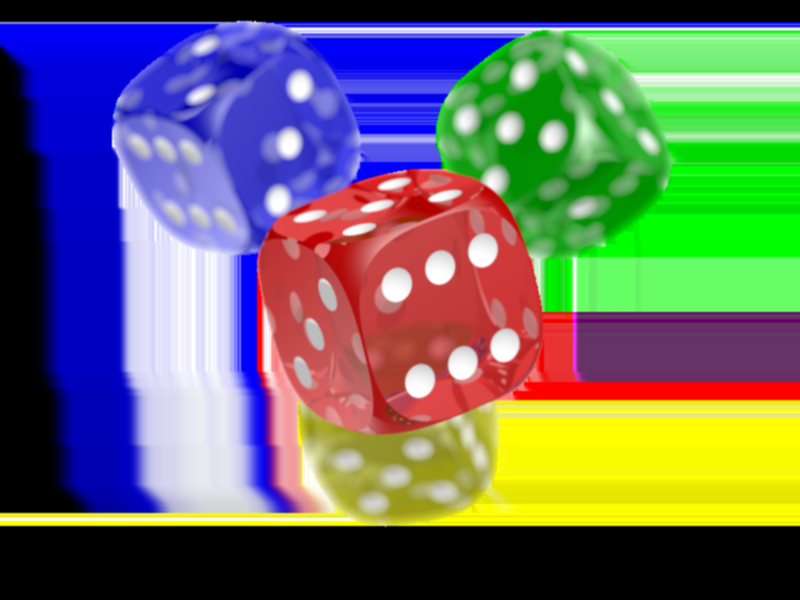

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
from urllib.request import urlopen
import numpy as np

# Función para cargar una imagen desde una URL
def load_image_from_url(url):
    resp = urlopen(url)
    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    return image

# URL de la imagen de ejemplo (puedes reemplazarla con cualquier URL de imagen de tu elección)
image_url = "https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png"

# Cargar la imagen
image = load_image_from_url(image_url)

# Convertir la imagen a escala de grises
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# Aplicar un desenfoque gaussiano
blurred_image = cv2.GaussianBlur(image, (3, 3), 0)

# Mostrar la imagen original, la imagen en escala de grises y la imagen desenfocada
print("Imagen Original:")
cv2_imshow(image)
print("Imagen en Escala de Grises:")
cv2_imshow(gray_image)
print("Imagen Desenfocada:")
cv2_imshow(blurred_image)


***Actividad rapida***

Realice una busqueda rapida en internet y mencione 4 tipos de filtros, apliquelos a las imagenes

Imagen detección de bordes:


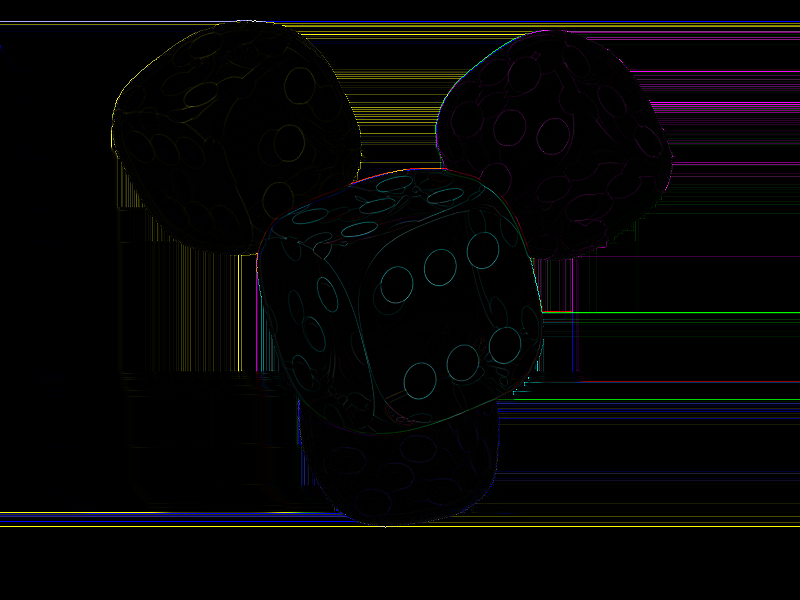

In [ ]:
#Laplaciano, cani, binarización

import cv2


# Aplicar filtro laplaciano
edges = cv2.Laplacian(image, cv2.CV_64F)

# Mostrar la imagen original y los bordes realzados
print("Imagen detección de bordes:")
cv2_imshow(edges)

***Datos Biomedicos con Volumen***

***Preprocesamiento con dataset MNIST***

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets

# Cargando el conjunto de datos MNIST
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalizando los valores de los píxeles de 0-255 a 0-1 para mejorar la convergencia del entrenamiento
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Redimensionando las imágenes para añadir un canal de color (grises) - necesario para la capa convolucional
# Las imágenes originales en MNIST son en escala de grises y tienen un tamaño de 28x28. Las CNNs esperan un número de canales, por lo que expandimos las dimensiones de los datos para incluirlo.
train_images = tf.expand_dims(train_images, -1)  # Transforma (60000, 28, 28) a (60000, 28, 28, 1)
test_images = tf.expand_dims(test_images, -1)  # Transforma (10000, 28, 28) a (10000, 28, 28, 1)

# Opcionalmente, podrías aplicar alguna técnica de aumento de datos aquí si lo consideras necesario
# Por ejemplo, un giro aleatorio de las imágenes:
# train_images = tf.image.random_rotation(train_images, 0.1)

print("Forma de los datos de entrenamiento:", train_images.shape)
print("Forma de los datos de prueba:", test_images.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de los datos de entrenamiento: (60000, 28, 28, 1)
Forma de los datos de prueba: (10000, 28, 28, 1)


In [ ]:
test_images[0,:,:,:].shape

TensorShape([28, 28, 1])

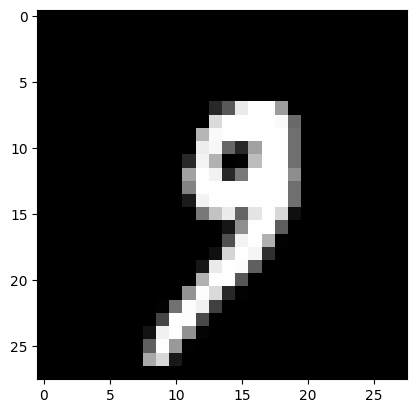

In [ ]:
import matplotlib.pyplot as plt #Importar plt para visualizar las imagenes

plt.imshow(test_images[1000,:,:,:],cmap = 'gray')

In [ ]:
def add_salt_pepper_noise(image):
    row, col = image.shape
    s_vs_p = 0.5
    amount = 0.4
    noisy = np.copy(image)

    # Sal
    num_salt = np.ceil(amount * image.size * s_vs_p)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 1

    # Pimienta
    num_pepper = np.ceil(amount * image.size * (1. - s_vs_p))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

# Aplicar filtro y ruido a todo el conjunto de datos
processed_images = []
for i in range(len(train_images)):
    image = np.array(train_images[i] * 255, dtype=np.uint8).reshape(28, 28)
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    noisy_image = add_salt_pepper_noise(blurred_image)
    processed_images.append(noisy_image)

# Convertir la lista de imágenes procesadas a un array de NumPy
processed_images = np.array(processed_images)


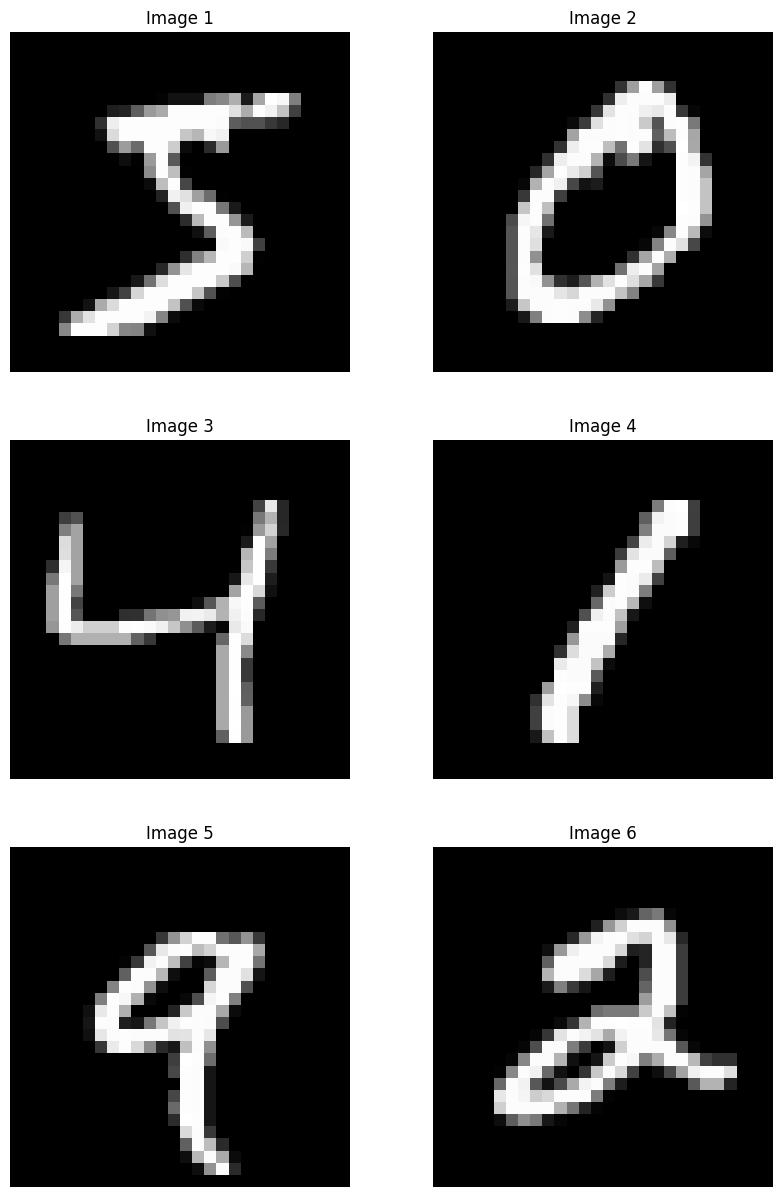

In [ ]:
# Mostrando las primeras 6 imágenes en una cuadrícula 3x2
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')#train_images
    ax.title.set_text(f'Image {i+1}')
    ax.axis('off')
plt.show()

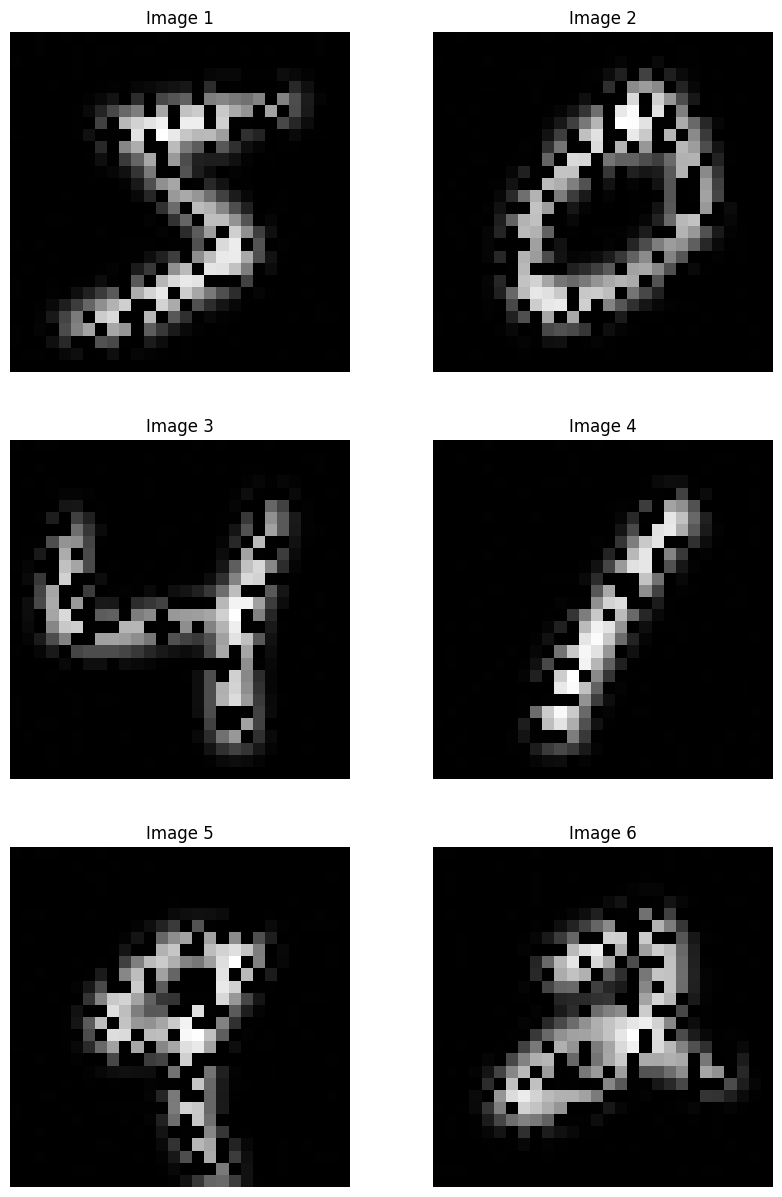

In [ ]:
# Mostrando las primeras 6 imágenes en una cuadrícula 3x2
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for i, ax in enumerate(axes.flat):
    ax.imshow(processed_images[i], cmap='gray')#train_images
    ax.title.set_text(f'Image {i+1}')
    ax.axis('off')
plt.show()

# **Entrenamiento del Modelo de Red Neuronal Convolucional - TensorFlow**

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, metrics
from tensorflow.keras.utils import plot_model

#https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D
# Definiendo el modelo
model = models.Sequential()
# Primera capa convolucional
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
# Segunda capa convolucional
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# Tercera capa convolucional
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Aplanando la salida para las capas densas
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# Compilando el modelo
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Visualizando el resumen del modelo
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

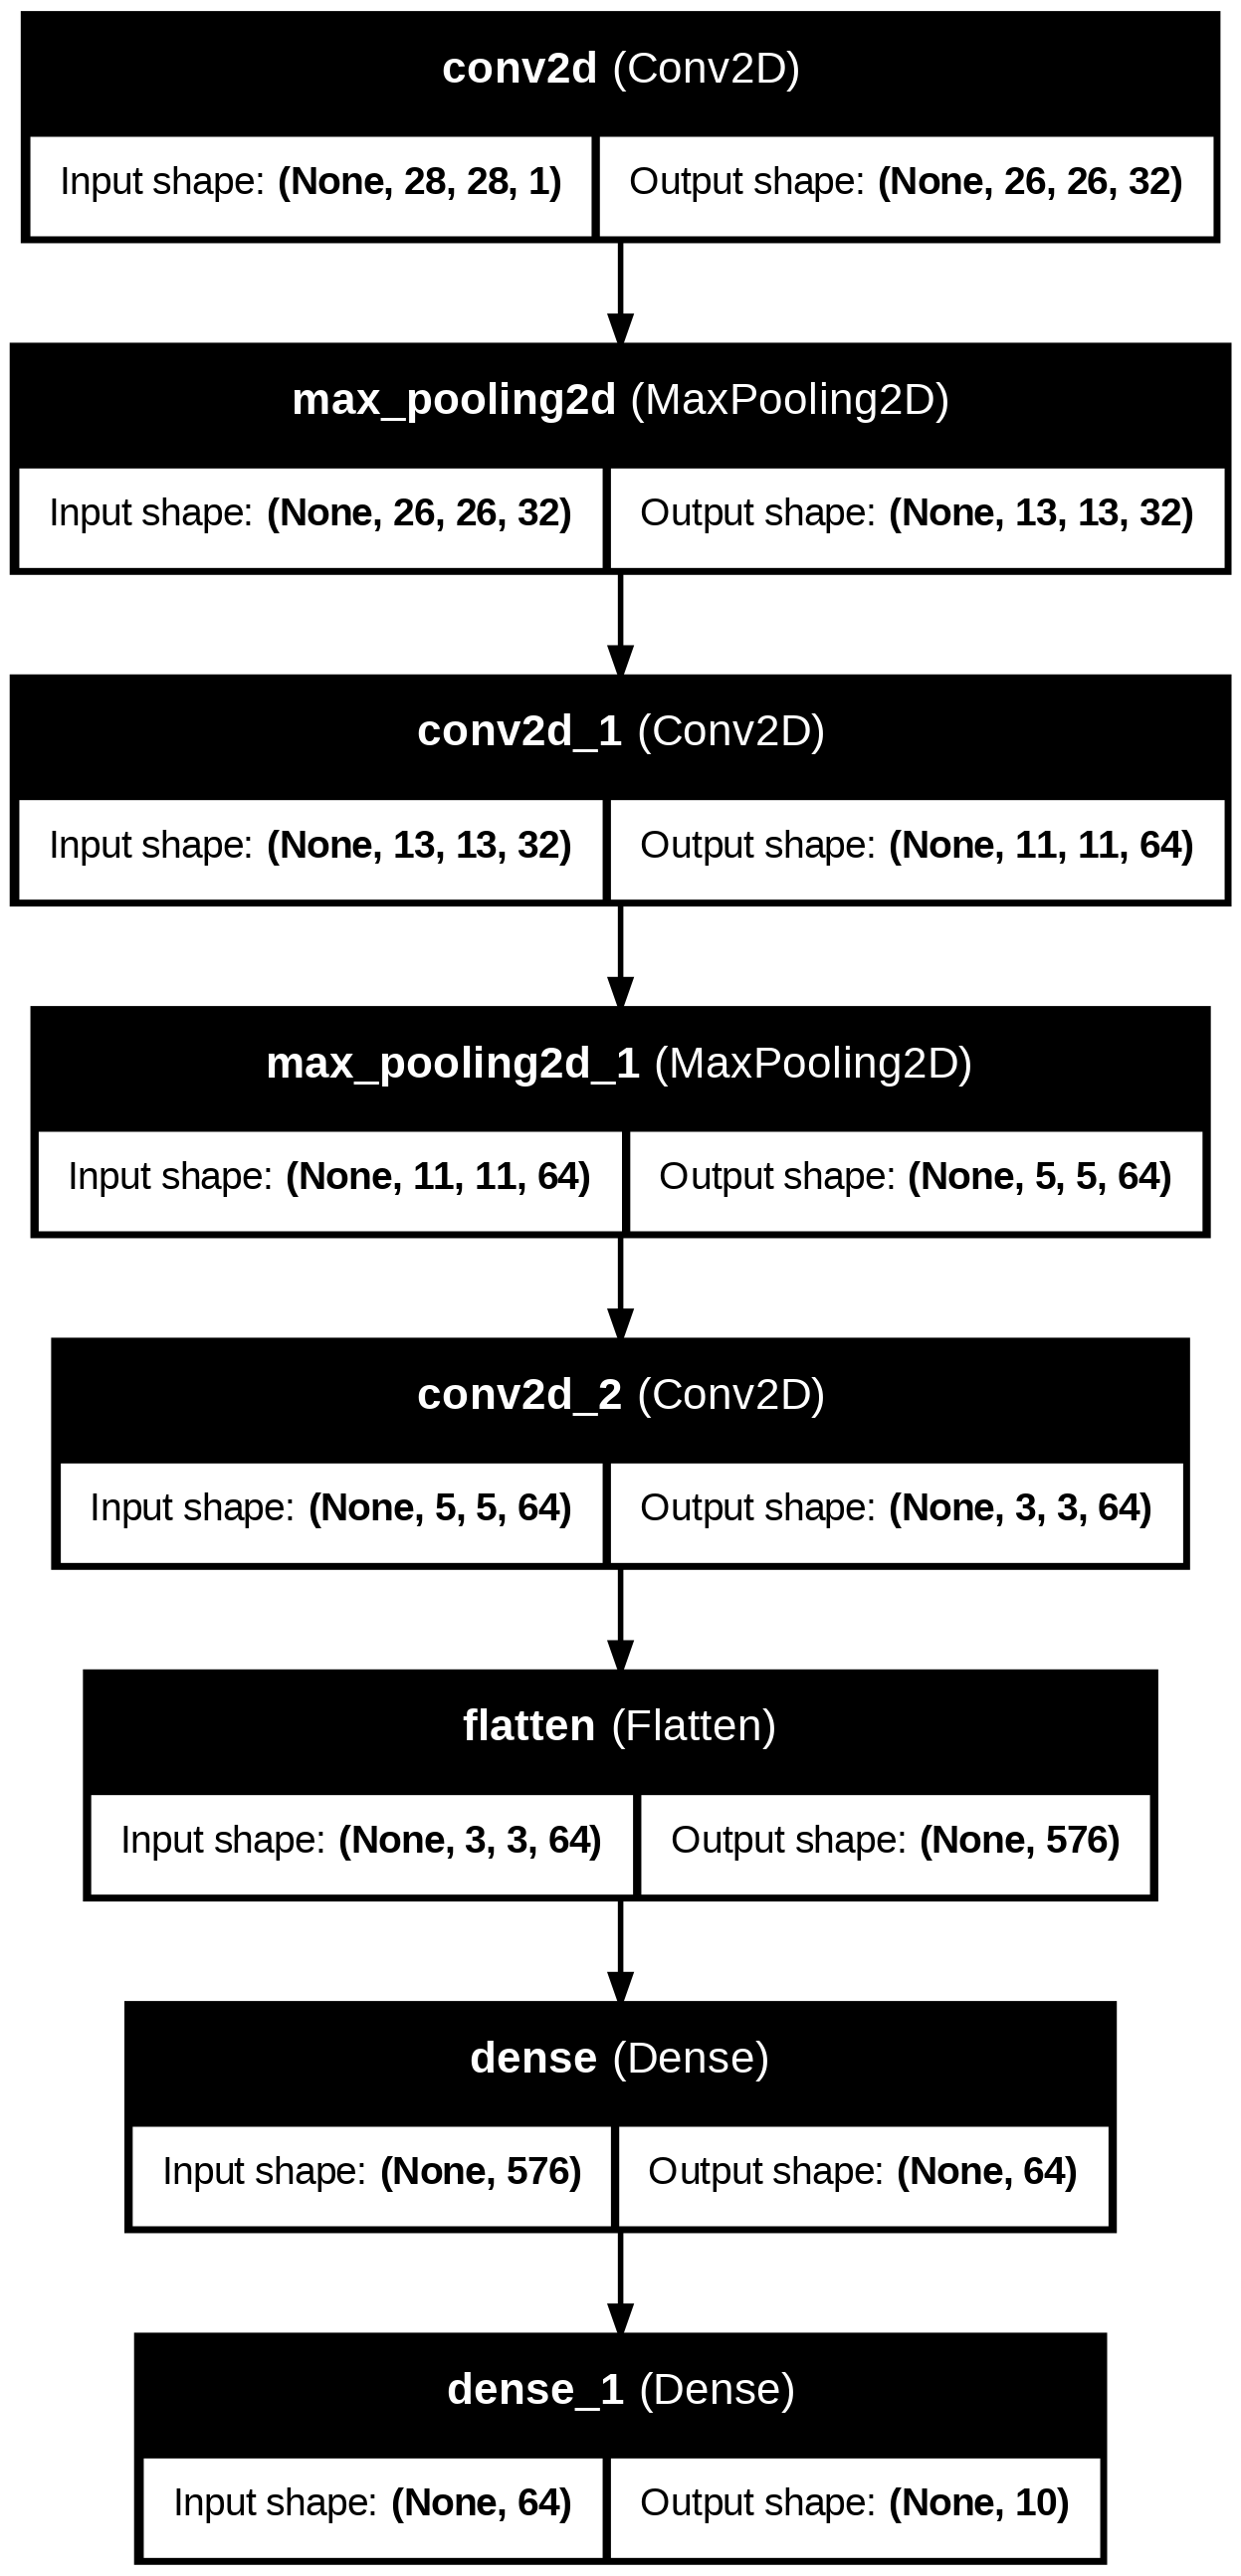

In [ ]:
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)


In [ ]:
# Entrenando el modelo
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8961 - loss: 0.3335 - val_accuracy: 0.9828 - val_loss: 0.0522
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9844 - loss: 0.0492 - val_accuracy: 0.9893 - val_loss: 0.0325
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9900 - loss: 0.0322 - val_accuracy: 0.9833 - val_loss: 0.0525
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9927 - loss: 0.0230 - val_accuracy: 0.9922 - val_loss: 0.0244
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9942 - loss: 0.0196 - val_accuracy: 0.9901 - val_loss: 0.0353


In [ ]:
#Guardar mi modelo
tf.saved_model.save(model, 'mi_modelo_saved_model')  # Para TensorFlow

***Actividad rapida***

Como se implementaria el guardado del modelo en el entrenamiento (recordar Callback)

In [ ]:
from keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint('model_checkpoint.h5',
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      mode='max')

model.fit(X_train, y_train,
          epochs=10,
          batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=[checkpoint_callback])

NameError: name 'X_train' is not defined

In [ ]:
# Graficando la precisión y la pérdida
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Evaluando el modelo
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy de Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

# Evaluando el modelo con diferentes métricas
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# Asegúrate de que los labels y las predicciones sean todos enteros para las métricas
test_labels = test_labels.astype(int)
y_pred_classes = y_pred_classes.astype(int)

print("\nReporte de clasificación")
print(classification_report(test_labels, y_pred_classes))

print("\nPrecisión del modelo:", accuracy_score(test_labels, y_pred_classes))
print("Recall del modelo:", recall_score(test_labels, y_pred_classes, average='weighted'))
print("F1-score del modelo:", f1_score(test_labels, y_pred_classes, average='weighted'))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns  # Para una visualización más bonita de la matriz de confusión

# Prediciendo las etiquetas para las imágenes de prueba
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir las probabilidades a etiquetas de clase

# Generando la matriz de confusión
cm = confusion_matrix(test_labels, y_pred_classes)

# Visualizando la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Verdaderas')
plt.xlabel('Etiquetas Predichas')
plt.show()


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Definir las transformaciones: Convertir los datos a tensores y normalizarlos
# MNIST tiene imágenes en escala de grises, por lo que solo hay un canal de color
# La media y la desviación estándar se establecen en 0.5 para transformar [0, 1] a [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descargar y cargar los conjuntos de datos de entrenamiento y prueba con las transformaciones definidas
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

# Crear DataLoader para gestionar lotes de datos y barajarlos para el entrenamiento
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Mostrar el tamaño del lote de datos y la transformación aplicada
for images, labels in train_loader:
    print(f"Shape of images in a batch: {images.shape}")
    print(f"Shape of labels in a batch: {labels.shape}")
    break


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Importación de las bibliotecas necesarias. torch es la principal biblioteca de PyTorch,
# nn contiene módulos y clases para construir redes neuronales,
# optim contiene optimizadores como Adam,
# datasets y transforms son para cargar y transformar conjuntos de datos,
# DataLoader es una utilidad para cargar datos en lotes.

class ConvNet(nn.Module):
    # Definición de la clase ConvNet, que hereda de nn.Module.
    # Esta clase define la arquitectura de la red neuronal convolucional.

    def __init__(self):
        super(ConvNet, self).__init__()
        # Inicializa la clase base nn.Module.

        # Definición de las capas de la red:
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        # Primera capa convolucional que toma 1 canal de entrada (imágenes en escala de grises),
        # produce 32 canales de salida, kernel de tamaño 3 y stride de 1.

        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        # Segunda capa convolucional que toma 32 canales de entrada,
        # produce 64 canales de salida, kernel de tamaño 3 y stride de 1.

        self.dropout1 = nn.Dropout(0.25)
        # Capa de dropout para reducir el sobreajuste, descarta el 25% de los datos.

        self.dropout2 = nn.Dropout(0.5)
        # Otra capa de dropout que descarta el 50% de los datos.

        self.fc1 = nn.Linear(9216, 128)
        # Primera capa completamente conectada que toma 9216 entradas y produce 128 salidas.

        self.fc2 = nn.Linear(128, 10)
        # Segunda capa completamente conectada que toma 128 entradas y produce 10 salidas (para las 10 clases de MNIST).

    def forward(self, x):
        # Define cómo pasa la entrada x a través de la red (propagación hacia adelante).

        x = self.conv1(x)
        x = nn.functional.relu(x)
        # Aplica la primera capa convolucional y luego una función de activación ReLU.

        x = self.conv2(x)
        x = nn.functional.relu(x)
        # Aplica la segunda capa convolucional y luego una función de activación ReLU.

        x = nn.functional.max_pool2d(x, 2)
        # Aplica un max pooling con un kernel de tamaño 2.

        x = self.dropout1(x)
        # Aplica la primera capa de dropout.

        x = torch.flatten(x, 1)
        # Aplana el tensor para la entrada a la capa completamente conectada.

        x = self.fc1(x)
        x = nn.functional.relu(x)
        # Aplica la primera capa completamente conectada y una función de activación ReLU.

        x = self.dropout2(x)
        # Aplica la segunda capa de dropout.

        x = self.fc2(x)
        # Aplica la segunda capa completamente conectada.

        output = nn.functional.log_softmax(x, dim=1)
        # Aplica la función log_softmax en las salidas para obtener probabilidades logarítmicas.

        return output
        # Retorna el output final de la red.

# Determinar si hay una GPU disponible y configurar PyTorch para usarla
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = ConvNet().to(device)  # Mover el modelo a la GPU si está disponible

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())


In [ ]:
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

num_epochs = 3
for epoch in range(num_epochs):
    # Entrenamiento
    model.train()  # Poner el modelo en modo entrenamiento
    train_loss = 0  # Inicializar la pérdida de entrenamiento
    correct_train = 0  # Contador de predicciones correctas en el conjunto de entrenamiento

    # Iterar sobre los lotes de datos del conjunto de entrenamiento
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)  # Mover los datos y las etiquetas al dispositivo (GPU o CPU)
        optimizer.zero_grad()  # Limpiar los gradientes
        output = model(data)  # Pasar los datos a través del modelo
        loss = criterion(output, target)  # Calcular la pérdida
        loss.backward()  # Realizar la retropropagación para calcular los gradientes
        optimizer.step()  # Actualizar los pesos del modelo
        train_loss += loss.item() * data.size(0)  # Acumular la pérdida total
        _, predicted = torch.max(output.data, 1)  # Obtener las predicciones
        correct_train += (predicted == target).sum().item()  # Contar las predicciones correctas

    # Calcular y almacenar la pérdida y precisión promedio del entrenamiento
    train_losses.append(train_loss / len(train_loader.dataset))
    train_accuracies.append(100 * correct_train / len(train_loader.dataset))

    # Validación
    model.eval()  # Poner el modelo en modo evaluación
    valid_loss = 0  # Inicializar la pérdida de validación
    correct_valid = 0  # Contador de predicciones correctas en el conjunto de validación

    # Desactivar el cálculo de gradientes para la validación
    with torch.no_grad():
        # Iterar sobre los lotes de datos del conjunto de validación
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)  # Mover los datos y las etiquetas al dispositivo
            output = model(data)  # Pasar los datos a través del modelo
            loss = criterion(output, target)  # Calcular la pérdida
            valid_loss += loss.item() * data.size(0)  # Acumular la pérdida total
            _, predicted = torch.max(output.data, 1)  # Obtener las predicciones
            correct_valid += (predicted == target).sum().item()  # Contar las predicciones correctas

    # Calcular y almacenar la pérdida y precisión promedio de la validación
    valid_losses.append(valid_loss / len(test_loader.dataset))
    valid_accuracies.append(100 * correct_valid / len(test_loader.dataset))

    # Imprimir la pérdida y precisión para cada época
    print(f'Época {epoch+1}, Pérdida de Entrenamiento: {train_losses[-1]}, Precisión de Entrenamiento: {train_accuracies[-1]}%')
    print(f'Época {epoch+1}, Pérdida de Validación: {valid_losses[-1]}, Precisión de Validación: {valid_accuracies[-1]}%')

In [ ]:
# Graficar los resultados
plt.figure(figsize=(12, 6))

# Graficar la pérdida de entrenamiento y validación
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Pérdida de Entrenamiento')
plt.plot(valid_losses, label='Pérdida de Validación')
plt.title('Pérdida durante el entrenamiento y la validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Graficar la precisión de entrenamiento y validación
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Precisión de Entrenamiento')
plt.plot(valid_accuracies, label='Precisión de Validación')
plt.title('Precisión durante el entrenamiento y la validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión (%)')
plt.legend()

plt.show()